In [39]:
import sys, os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# ML and XAI Libraries
import xgboost as xgb
import lightgbm as lgb
import joblib
import shap

from config.config import config
paths = config['paths']

# Set plot styling for presentation quality
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

In [40]:
# --- 1. Load Validation Data ---
# We need a sample of the validation data for Permutation Importance
VAL_DATA_PATH = paths.sampled_val_data 
print(f"Loading validation sample from {VAL_DATA_PATH}...")

import dask.dataframe as dd
# Taking a 5% sample to keep permutation importance fast
df_val = dd.read_parquet(VAL_DATA_PATH).sample(frac=0.05, random_state=42).compute()

y_val = df_val['target']
X_val = df_val.drop(columns=['target'])
feature_names = X_val.columns.tolist()

print(f"Validation sample shape: {X_val.shape}")

# --- 2. Load Models ---
# Update these filenames to match your actual saved model names
try:
    lr_model = joblib.load(os.path.join(paths.models_dir, "model_logistic.pkl"))
    xgb_model = joblib.load(os.path.join(paths.models_dir, "model_xgboost.pkl"))
    lgb_model = joblib.load(os.path.join(paths.models_dir, "model_lightgbm.pkl"))
    ensemble_model = joblib.load(os.path.join(paths.models_dir, "model_ensemble.pkl"))
    print("All models loaded successfully.")
except Exception as e:
    print(f"Warning: Could not load one or more models. Error: {e}")

Loading validation sample from D:/Projects/credit_risk_scoring/data/features_sampled/val_data.parquet...
Validation sample shape: (4999, 63)
All models loaded successfully.


In [41]:
def plot_importance(importance_df, title, filename, top_n=15):
    """Plots and saves a standardized horizontal bar chart for feature importance."""
    top_features = importance_df.head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=top_features, 
        palette='viridis', 
        ax=ax
    )
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Relative Importance / Weight', fontsize=14)
    ax.set_ylabel('')
    
    plt.tight_layout()
    
    out_path = os.path.join(paths.eda_dir, filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()

In [42]:
print("Looking inside the lr_model object...")

# This prints every method and attribute attached to the model
attributes = dir(lr_model)

# Filter for likely candidates where the weights might be stored
print("Possible coefficient attributes:")
for attr in attributes:
    if 'coef' in attr.lower() or 'weight' in attr.lower() or 'model' in attr.lower():
        print(f" - {attr}")

Looking inside the lr_model object...
Possible coefficient attributes:
 - class_weight
 - get_coefficients
 - is_dask_model
 - model


Extracting Logistic Regression coefficients...
Number of original feature_names: 63
Number of coefficients found: 59

Could not find transformed names. Using generic placeholders (Feature_0, Feature_1, etc.) to allow plotting.

Top 5 features found:
                   Feature  Importance
1    Transformed_Feature_1    0.768853
8    Transformed_Feature_8    0.728081
25  Transformed_Feature_25    0.423856
24  Transformed_Feature_24    0.403818
14  Transformed_Feature_14    0.382652
Saved: D:/Projects/credit_risk_scoring/results/eda\lr_importance.png


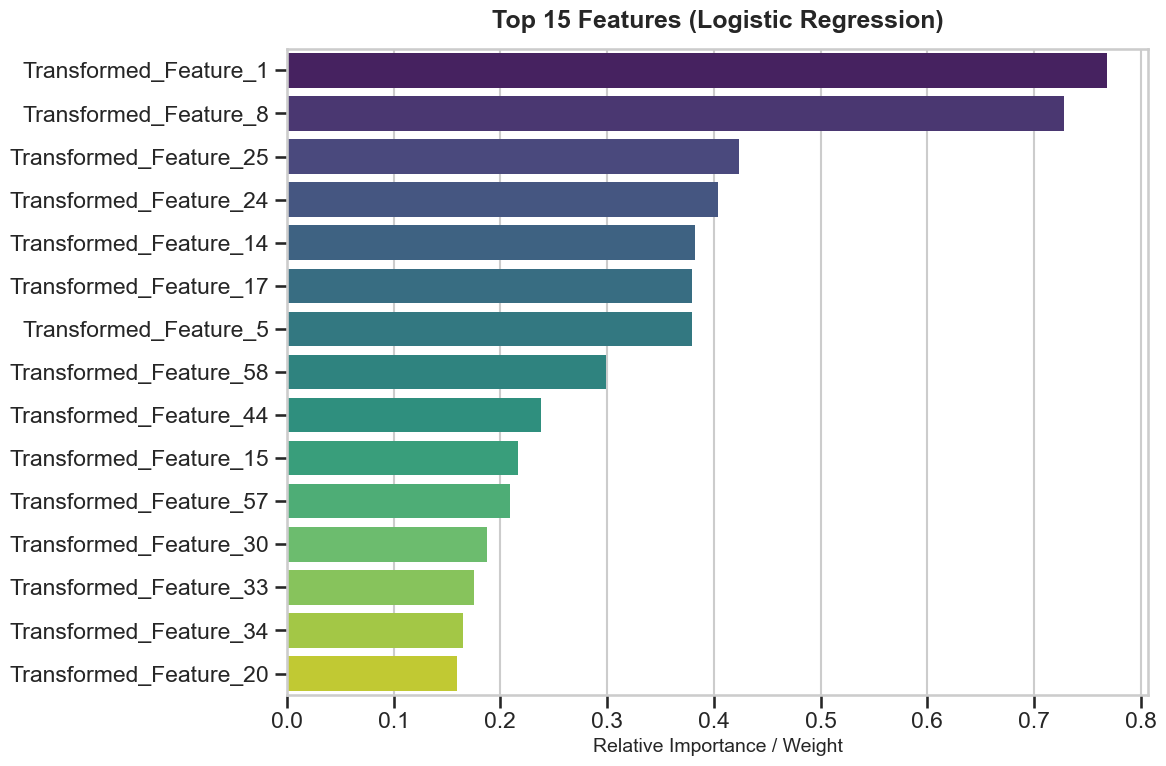

In [43]:
print("Extracting Logistic Regression coefficients...")

# 1. Extract coefficients
try:
    coefs = lr_model.get_coefficients()
    coefs = np.abs(np.array(coefs))
    if len(coefs.shape) > 1:
        coefs = coefs[0]
except Exception:
    coefs = np.abs(lr_model.model.coef_[0])

print(f"Number of original feature_names: {len(feature_names)}")
print(f"Number of coefficients found: {len(coefs)}")

# 2. Reconcile Feature Names
actual_features = feature_names

if len(feature_names) != len(coefs):
    print("\nWARNING: Length mismatch detected! Trying to extract transformed feature names from the model...")
    
    # Check if the underlying scikit-learn model saved the transformed names
    if hasattr(lr_model.model, 'feature_names_in_'):
        actual_features = lr_model.model.feature_names_in_
        print("Success! Extracted transformed feature names.")
    else:
        print("Could not find transformed names. Using generic placeholders (Feature_0, Feature_1, etc.) to allow plotting.")
        actual_features = [f"Transformed_Feature_{i}" for i in range(len(coefs))]

# 3. Create the DataFrame safely
lr_imp_df = pd.DataFrame({
    'Feature': actual_features,
    'Importance': coefs
}).sort_values(by='Importance', ascending=False)

print(f"\nTop 5 features found:\n{lr_imp_df.head()}")

# 4. Plot the chart
plot_importance(
    lr_imp_df, 
    title='Top 15 Features (Logistic Regression)', 
    filename='lr_importance.png'
)

In [45]:
# Assuming your preprocessed training data is called X_train_processed
actual_features = list(X_train_processed.columns)

print(f"Number of columns in processed data: {len(actual_features)}")
print(actual_features[:5])

NameError: name 'X_train_processed' is not defined

In [44]:
print("Extracting Logistic Regression coefficients...")

# 1. Extract coefficients using the custom wrapper's methods
try:
    # Try calling the custom method
    coefs = lr_model.get_coefficients()
    
    # Ensure it's a 1D numpy array and take absolute values for importance
    coefs = np.abs(np.array(coefs))
    if len(coefs.shape) > 1:
        coefs = coefs[0]
        
except Exception as e:
    print(f"get_coefficients() failed ({e}), falling back to .model attribute...")
    # Fallback: access the underlying sklearn/dask-ml model inside the wrapper
    coefs = np.abs(lr_model.model.coef_[0])

# 2. Create the DataFrame
lr_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefs
}).sort_values(by='Importance', ascending=False)

print(f"Top 5 features found:\n{lr_imp_df.head()}")

# 3. Plot the chart
plot_importance(
    lr_imp_df, 
    title='Top 15 Features (Logistic Regression)', 
    filename='lr_importance.png'
)

Extracting Logistic Regression coefficients...
get_coefficients() failed (bad operand type for abs(): 'dict'), falling back to .model attribute...


ValueError: All arrays must be of the same length

In [ ]:
print("Starting XGBoost importance extraction...")

# 1. Verify the model actually exists in memory
print(f"Model type: {type(xgb_model)}")

# 2. Extract importance
if hasattr(xgb_model, 'feature_importances_'):
    xgb_importances = xgb_model.feature_importances_
else:
    xgb_importances_dict = xgb_model.get_score(importance_type='gain')
    xgb_importances = [xgb_importances_dict.get(f, 0.0) for f in feature_names]

# 3. Create DataFrame
xgb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

print(f"Top 5 features found:\n{xgb_imp_df.head()}")

# 4. Plot
plot_importance(
    xgb_imp_df, 
    title='Top 15 Features (XGBoost)', 
    filename='xgb_importance.png'
)

Starting XGBoost importance extraction...


NameError: name 'xgb_model' is not defined

In [ ]:
if 'ensemble_model' in locals():
    print("Calculating Permutation Importance for the Ensemble Model...")
    print("(This may take a few minutes as it re-evaluates the ensemble multiple times)")
    
    # Calculate permutation importance using ROC AUC as the scoring metric
    result = permutation_importance(
        ensemble_model, 
        X_val, 
        y_val, 
        n_repeats=5,       # Number of times to shuffle each feature
        random_state=42, 
        n_jobs=-1,         # Use all available CPU cores
        scoring='roc_auc'  # Aligns with your project's primary metric
    )
    
    # Extract the mean importance across the repeats
    ensemble_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': result.importances_mean
    }).sort_values(by='Importance', ascending=False)
    
    # Save the raw data for your presentation tables
    ensemble_imp_df.to_csv(os.path.join(paths.eda_dir, "ensemble_importance_data.csv"), index=False)
    
    # Plot it
    plot_importance(
        ensemble_imp_df, 
        title='Top 15 Features (Ensemble - Permutation Importance)', 
        filename='ensemble_importance.png'
    )